## Name : Sulaiman Alfawzan

# M1.Ex4: Modeling Non-linear Patterns

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex4_non-linear.ipynb)
- Raw Dataset: [bmi_and_life_expectancy.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv)

In [1]:
import pandas as pd
import sklearn

### Step 1. Load the data


In [ ]:
# pd.read_csv("../../../datasets/bmi_and_life_expectancy.csv").head()

,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


In [3]:
from pathlib import Path

DATA_PATH = Path('./Data/bmi_and_life_expectancy.csv')
print(DATA_PATH.resolve())
print(DATA_PATH.exists())
df = pd.read_csv(DATA_PATH)
df.head()


C:\Users\xxslo\OneDrive\Desktop\AAI-bootcamp\student\C3\M1\Data\bmi_and_life_expectancy.csv
True


,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


### Step 2.a Assign variables `X` to the features and `y` to the target

In [4]:
x = df['BMI'].values
y = df['Life expectancy'].values

### Step 2.b print the type of each

In [5]:
type(x), type(y)

(numpy.ndarray, numpy.ndarray)

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [6]:
# Both of y and x are numerical variables.
# Since the target y is numerical  this is a regression.

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [7]:
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (163,)
y shape: (163,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [9]:
df[['BMI', 'Life expectancy']].agg(['min', 'max','median','mean', 'std'])

,BMI,Life expectancy
min,19.866920,44.500000
max,30.995630,84.600000
median,25.320540,71.800000
mean,24.792378,69.666933
std,2.427900,8.981933


### Step 5. Plot the feature vs the target

Text(0.5, 1.0, 'BMI vs Life expectancy')

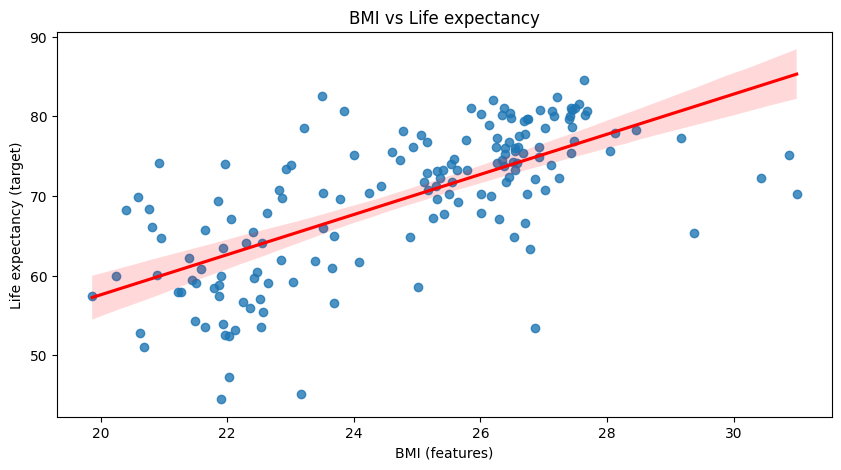

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.regplot(x='BMI', y='Life expectancy', data=df, line_kws={'color':'red'})
plt.xlabel('BMI (features)')
plt.ylabel('Life expectancy (target)')
plt.title('BMI vs Life expectancy')

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [15]:
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(df['BMI'], df['Life expectancy'])
print("its incerasing by",r_value**2)

its incerasing by 0.4634455864661574


### Step 7. Make two modeling techniques

First model is just a Linear Regression model: `from sklearn.linear_model import LinearRegression`

Second model: Use one of the previously mentioned methods to model a non-linear relationship

1. `from sklearn.tree import DecisionTreeRegressor`
2. or `from sklearn.preprocessing import PolynomialFeatures`

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


model_Linear = LinearRegression()

polynomial_expansion  = PolynomialFeatures(
    degree=3, 
    include_bias=False
    )

model_poly = make_pipeline(
    polynomial_expansion,
    LinearRegression(),
)

### Step 8. Split the dataset into train and test sets

In [24]:
from sklearn.model_selection import train_test_split

X = x.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
)

### Step 9. Train both models on the training set

In [25]:
model_Linear.fit(X_train, y_train)
model_poly.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


### Step 10. Evaluate and compare which of the two models score better on the `train` set

Linear Regression score: 0.494 on training set
Polynomial Regression score: 0.576 on training set


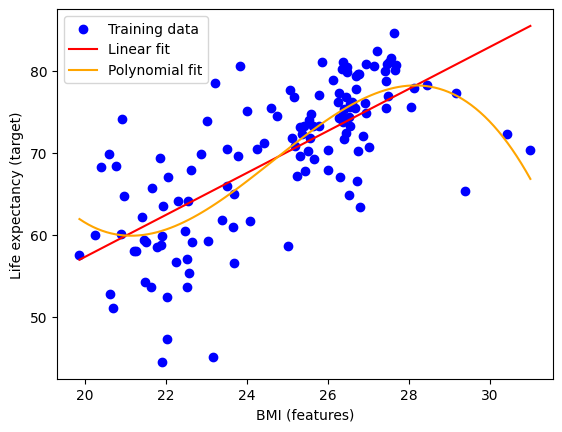

In [44]:
import numpy as np

y_Linear_pred = model_Linear.predict(X_train)
y_poly_pred = model_poly.predict(X_train)

plt.scatter(X_train, y_train, label='Training data', marker='o', color='blue')


x_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
y_line_Linear = model_Linear.predict(x_line)
y_line_poly = model_poly.predict(x_line)
plt.plot(x_line, y_line_Linear, color="red", label="Linear fit")
plt.plot(x_line, y_line_poly, color="orange", label="Polynomial fit")
plt.xlabel('BMI (features)')
plt.ylabel('Life expectancy (target)')
plt.legend()

comparison = pd.DataFrame({
    "Train": y_train.round(2),
    "predicted model Linear": y_Linear_pred.round(2),
    "predicted model Polynomial": y_poly_pred.round(2)

}).reset_index(drop=True)
comparison.sample(5)

score_linear_train = model_Linear.score(X_train, y_train)
score_poly_train = model_poly.score(X_train, y_train)

print(f"Linear Regression score: {score_linear_train:.3f} on training set")
print(f"Polynomial Regression score: {score_poly_train:.3f} on training set")

### Step 11. Evaluate and compare which of the two models score better on the `test` set